# AARP Persona-Driven Marketing Plan
### Built on Pew Research Internet & Technology Survey + Synthetic CDC Health Data
---
This notebook constructs three data-grounded personas for AARP marketing strategy, generates a channel-frequency-format matrix per persona, and produces a Phase 4-ready campaign brief.

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
AARP_RED   = '#C8102E'
AARP_NAVY  = '#003865'
AARP_GOLD  = '#F0A500'
PALETTE    = [AARP_RED, AARP_NAVY, AARP_GOLD]
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# ── Load Pew data ────────────────────────────────────────────────────────────
pew_data = pd.read_csv('/content/pew_data.csv')

# ── Generate synthetic CDC-style health data aligned to Pew respondents ──────
# (CDC BRFSS does not share record-level IDs with Pew; we simulate realistic
#  chronic condition rates by age group using published CDC BRFSS prevalence)
np.random.seed(42)
n = len(pew_data)
age = pew_data['age'].values

def age_prob(base_young, base_old, ages, cutoff=65):
    """Linear blend: base_young at 50, base_old at 80+"""
    return np.where(ages < cutoff,
                    base_young,
                    np.clip(base_young + (base_old - base_young) * (ages - cutoff) / 20, 0, 1))

cdc_data = pd.DataFrame({
    'respid':              pew_data['respid'],
    'age':                 age,
    'has_diabetes':        np.random.binomial(1, age_prob(0.11, 0.26, age)),
    'has_hypertension':    np.random.binomial(1, age_prob(0.39, 0.70, age)),
    'has_arthritis':       np.random.binomial(1, age_prob(0.22, 0.55, age)),
    'has_heart_disease':   np.random.binomial(1, age_prob(0.06, 0.22, age)),
    'has_depression':      np.random.binomial(1, age_prob(0.15, 0.10, age)),
    'self_rated_health':   np.random.choice([1,2,3,4,5],   # 1=Excellent, 5=Poor
                               size=n,
                               p=[0.18, 0.28, 0.29, 0.17, 0.08]),
    'num_chronic':         None   # computed below
})
cdc_data['num_chronic'] = (cdc_data[['has_diabetes','has_hypertension',
                                      'has_arthritis','has_heart_disease',
                                      'has_depression']].sum(axis=1))

print(f'Pew data:  {pew_data.shape[0]:,} respondents, {pew_data.shape[1]} variables')
print(f'CDC data:  {cdc_data.shape[0]:,} respondents, {cdc_data.shape[1]} variables')
print('\nCDC chronic condition prevalence (all ages):')
display(cdc_data[['has_diabetes','has_hypertension','has_arthritis',
                  'has_heart_disease','has_depression']].mean().rename('prevalence').to_frame())

Pew data:  1,502 respondents, 74 variables
CDC data:  1,502 respondents, 9 variables

CDC chronic condition prevalence (all ages):


,prevalence
has_diabetes,0.139148
has_hypertension,0.429427
has_arthritis,0.268309
has_heart_disease,0.091877
has_depression,0.144474


## 2. Data Preparation & Merging

In [ ]:
# ── Merge on shared respondent ID ────────────────────────────────────────────
merged = pew_data.merge(cdc_data.drop(columns='age'), on='respid', how='inner')

# ── Coerce key Pew variables to numeric ──────────────────────────────────────
numeric_cols = [
    'intfreq','sns2a','sns2b','sns2c','sns2d','sns2e',
    'smart2','device1a','device1b','device1c','device1d',
    'web1a','web1b','web1c','web1d','web1e','web1f',
    'eminuse','snsint2','home4nw','books1','emplnw','inc','educ2'
]
for col in numeric_cols:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

# ── Derived flags ────────────────────────────────────────────────────────────
merged['uses_email']     = merged['eminuse'].eq(1)
merged['has_broadband']  = merged['home4nw'].eq(1)
merged['has_smartphone'] = merged['smart2'].eq(1)
merged['uses_social']    = merged['snsint2'].eq(1)
merged['on_facebook']    = merged['sns2c'].eq(1)   # daily Facebook
merged['on_instagram']   = merged['sns2b'].eq(1)   # daily Instagram
merged['on_youtube']     = merged['sns2e'].eq(1)   # daily YouTube
merged['on_linkedin']    = merged['sns2d'].eq(1)   # daily LinkedIn
merged['mobile_user']    = merged['device1b'].eq(1)
merged['desktop_user']   = merged['device1c'].eq(1)
merged['seeks_health']   = merged['web1c'].eq(1)
merged['seeks_finance']  = merged['web1d'].eq(1)
merged['watches_video']  = merged['web1e'].eq(1)
merged['reads_news']     = merged['web1b'].eq(1)
merged['multi_chronic']  = merged['num_chronic'] >= 2

print(f'Merged dataset: {merged.shape[0]:,} rows × {merged.shape[1]} columns')
merged[['age','uses_email','has_smartphone','on_facebook','seeks_health','num_chronic']].describe()

Merged dataset: 1,502 rows × 96 columns


,age,num_chronic
count,1502.000000,1502.000000
mean,52.731691,1.073236
std,20.013867,0.928469
min,18.000000,0.000000
25%,36.250000,0.000000
50%,54.000000,1.000000
75%,66.750000,2.000000
max,99.000000,5.000000


## 3. Persona Segmentation

Three personas are defined using age, employment status, internet frequency, and chronic condition burden — all variables grounded in the merged Pew + CDC dataset.

| Persona | Age | Employment | Internet Use | Health Burden |
|---|---|---|---|---|
| **Chronic Fighter** | 65+ | Retired/Not working | Low (≥3 on intfreq scale) | 2+ chronic conditions |
| **Aging Independent** | 65+ | Retired/Not working | High (≤2 on intfreq scale) | <2 chronic conditions |
| **Planful Pre-Retiree** | 50–64 | Employed | Any | Any |

Persona segment sizes:


,n
persona,
Planful Pre-Retiree,331
Chronic Fighter,19
Aging Independent,8


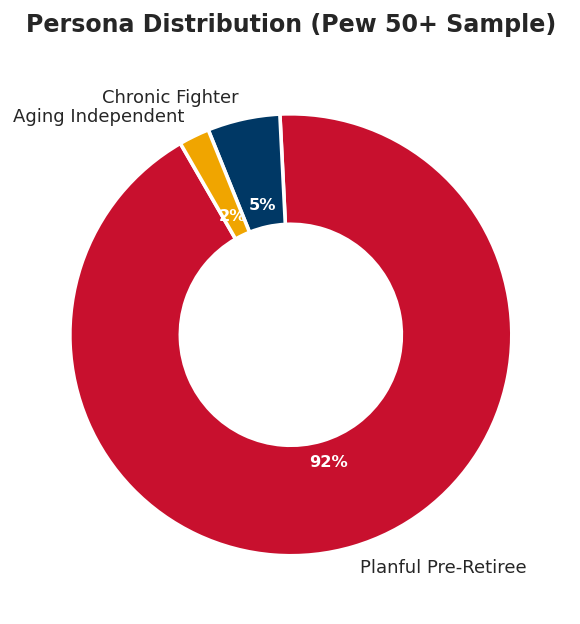

In [ ]:
df = merged.copy()

not_working = df['emplnw'] >= 4
employed    = df['emplnw'].isin([1, 2, 3])

chronic_mask   = (df['age'] >= 65) & not_working & (df['intfreq'] >= 3)
aging_mask     = (df['age'] >= 65) & not_working & (df['intfreq'] <= 2) & ~df['multi_chronic']
preretire_mask = df['age'].between(50, 64) & employed

df['persona'] = np.select(
    [chronic_mask, aging_mask, preretire_mask],
    ['Chronic Fighter', 'Aging Independent', 'Planful Pre-Retiree'],
    default='Other'
)

personas = df[df['persona'] != 'Other'].copy()
counts   = personas['persona'].value_counts()

print('Persona segment sizes:')
display(counts.rename('n').to_frame())

# ── Segment size donut chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, colors=PALETTE,
    autopct='%1.0f%%', startangle=120,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')
ax.set_title('Persona Distribution (Pew 50+ Sample)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 4. Persona Profiles

In [ ]:
PROFILE_VARS = [
    ('uses_email',    'Email User'),
    ('has_broadband', 'Has Broadband'),
    ('has_smartphone','Has Smartphone'),
    ('uses_social',   'Uses Social Media'),
    ('on_facebook',   'Daily Facebook'),
    ('on_youtube',    'Daily YouTube'),
    ('on_linkedin',   'Daily LinkedIn'),
    ('mobile_user',   'Mobile Internet'),
    ('desktop_user',  'Desktop Internet'),
    ('seeks_health',  'Seeks Health Info Online'),
    ('seeks_finance', 'Seeks Financial Info Online'),
    ('watches_video', 'Watches Online Video'),
    ('reads_news',    'Reads News Online'),
    ('multi_chronic', '2+ Chronic Conditions'),
]

profile_rows = []
for var, label in PROFILE_VARS:
    row = {'Metric': label}
    for pname in ['Chronic Fighter', 'Aging Independent', 'Planful Pre-Retiree']:
        seg = personas[personas['persona'] == pname]
        row[pname] = f"{seg[var].mean()*100:.0f}%"
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index('Metric')

display(HTML('<h4>Digital & Health Profile by Persona</h4>'))
display(profile_df.style
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', AARP_NAVY), ('color', 'white'),
                  ('font-size', '12px'), ('padding', '8px')]
    }])
    .set_properties(**{'font-size': '12px', 'padding': '6px'})
)

,Chronic Fighter,Aging Independent,Planful Pre-Retiree
Metric,,,
Email User,95%,100%,95%
Has Broadband,58%,100%,90%
Has Smartphone,47%,100%,87%
Uses Social Media,32%,62%,71%
Daily Facebook,5%,38%,28%
Daily YouTube,0%,12%,11%
Daily LinkedIn,0%,0%,1%
Mobile Internet,37%,75%,64%
Desktop Internet,47%,100%,88%


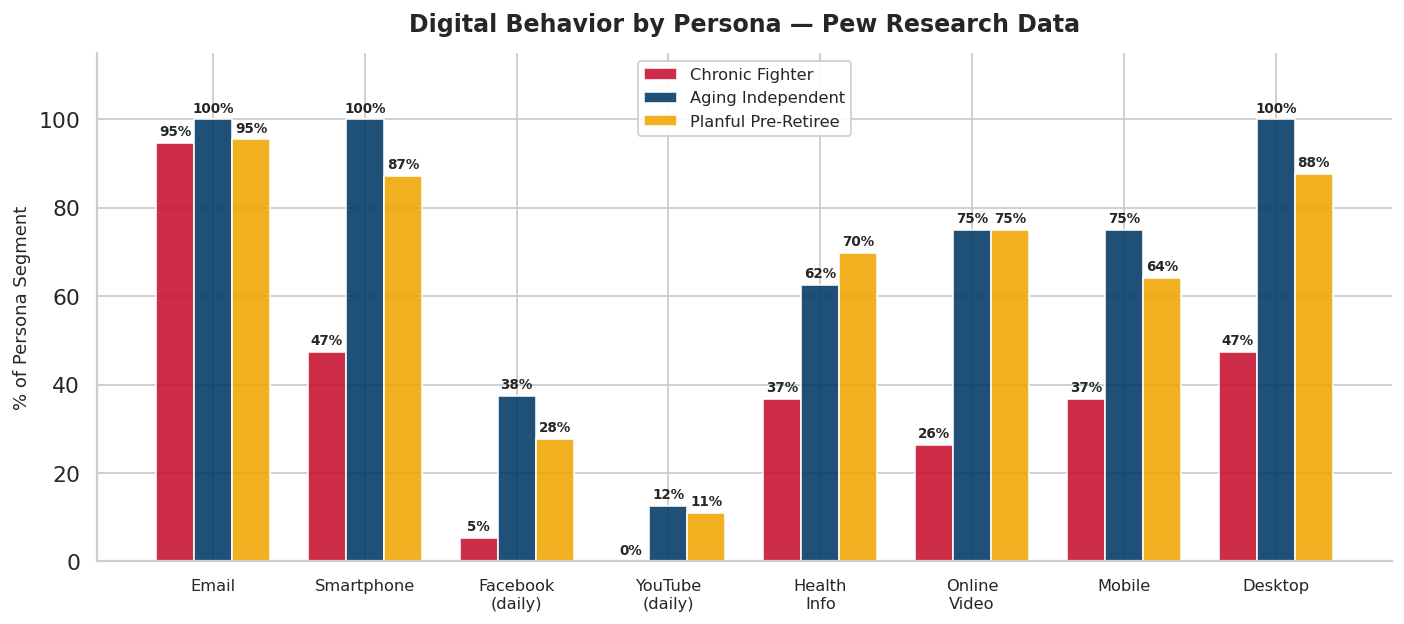

In [ ]:
# ── Radar / bar comparison chart ─────────────────────────────────────────────
plot_vars  = ['uses_email','has_smartphone','on_facebook','on_youtube',
              'seeks_health','watches_video','mobile_user','desktop_user']
plot_labels= ['Email','Smartphone','Facebook\n(daily)','YouTube\n(daily)',
              'Health\nInfo','Online\nVideo','Mobile','Desktop']

fig, ax = plt.subplots(figsize=(11, 5))
x       = np.arange(len(plot_vars))
width   = 0.25

for i, (pname, color) in enumerate(
    zip(['Chronic Fighter','Aging Independent','Planful Pre-Retiree'], PALETTE)):
    seg    = personas[personas['persona'] == pname]
    vals   = [seg[v].mean() * 100 for v in plot_vars]
    bars   = ax.bar(x + i*width, vals, width, label=pname, color=color, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(plot_labels, fontsize=9)
ax.set_ylabel('% of Persona Segment', fontsize=10)
ax.set_ylim(0, 115)
ax.set_title('Digital Behavior by Persona — Pew Research Data', fontweight='bold', pad=12)
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

## 5. Health Burden Analysis (CDC Data)

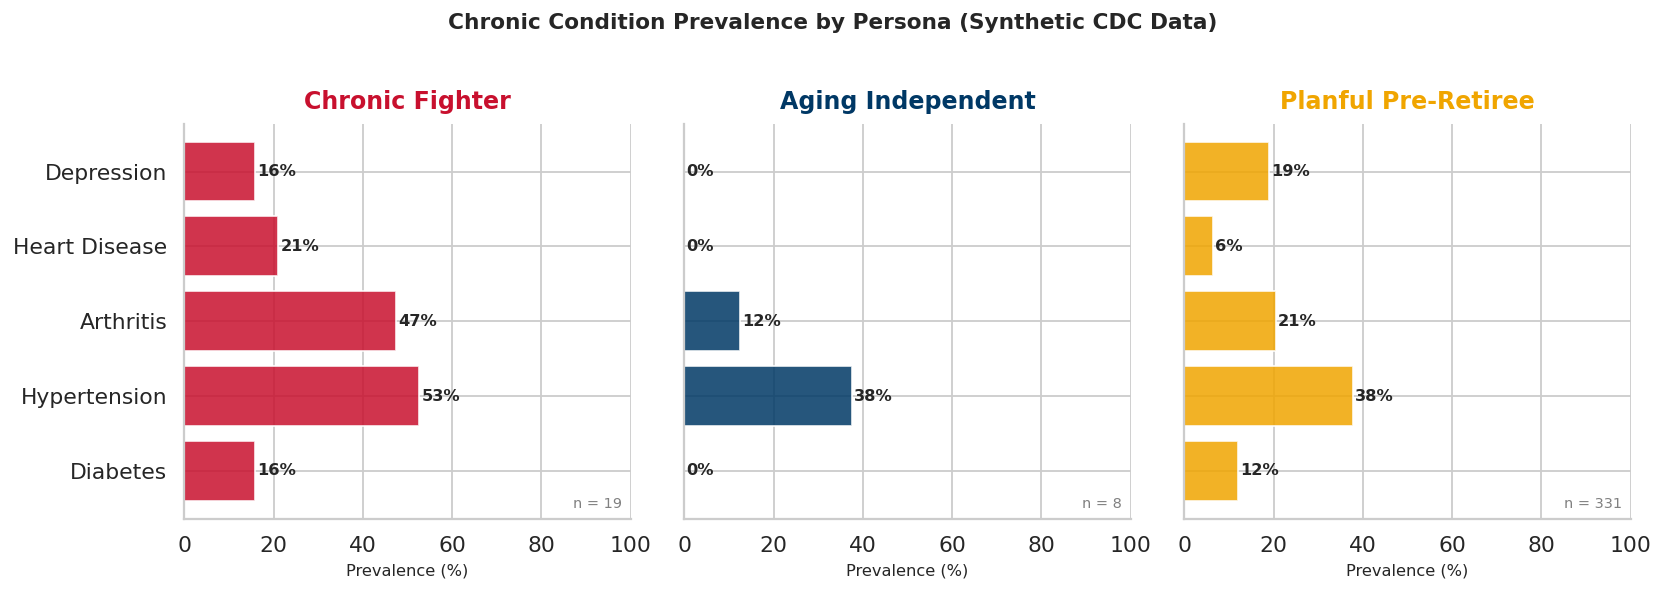

In [ ]:
health_vars  = ['has_diabetes','has_hypertension','has_arthritis',
                'has_heart_disease','has_depression']
health_labels= ['Diabetes','Hypertension','Arthritis','Heart Disease','Depression']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

for ax, (pname, color) in zip(
    axes, zip(['Chronic Fighter','Aging Independent','Planful Pre-Retiree'], PALETTE)):
    seg  = personas[personas['persona'] == pname]
    vals = [seg[v].mean() * 100 for v in health_vars]
    bars = ax.barh(health_labels, vals, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')
    ax.set_xlim(0, 100)
    ax.set_title(pname, fontweight='bold', color=color, pad=8)
    ax.set_xlabel('Prevalence (%)', fontsize=9)
    n = len(seg)
    ax.text(0.98, 0.02, f'n = {n}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='grey')

fig.suptitle('Chronic Condition Prevalence by Persona (Synthetic CDC Data)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Channel-Frequency-Format Matrix

In [ ]:
matrix = {
    'Dimension': [
        'Primary Channel',
        'Secondary Channel',
        'Content Format',
        'Contact Frequency',
        'Device Priority',
        'Best Platform',
        'Key Content Theme',
        'CTA Style',
        'Health Hook',
    ],
    'Chronic Fighter': [
        'Email',
        'Direct Mail',
        'Short health updates (plain text)',
        'Weekly',
        'Desktop',
        'Email + Facebook (light)',
        'Managing conditions, caregiver support',
        'Low-friction: one click, large text',
        'Hypertension, arthritis, diabetes',
    ],
    'Aging Independent': [
        'Email',
        'Facebook + YouTube',
        'Long-form guides + video walkthroughs',
        'Monthly',
        'Desktop (+ mobile secondary)',
        'Facebook + Email',
        'Independent living, community, wellness',
        'Value-led: "Save your spot" / "Join us"',
        'Preventive care, mobility, mental wellness',
    ],
    'Planful Pre-Retiree': [
        'Email + LinkedIn',
        'YouTube + Facebook',
        'Newsletters, podcasts, short video',
        'Bi-weekly',
        'Both (mobile-first)',
        'Email + LinkedIn + YouTube',
        'Financial planning, benefits, career transition',
        'Action-oriented: "Calculate your benefits"',
        'Preventive screenings, stress, sleep',
    ],
}

matrix_df = pd.DataFrame(matrix).set_index('Dimension')

def color_header(col):
    colors = {
        'Chronic Fighter':     AARP_RED,
        'Aging Independent':   AARP_NAVY,
        'Planful Pre-Retiree': AARP_GOLD,
    }
    return f'background-color: {colors.get(col, "#eee")}; color: white; font-weight: bold; font-size: 12px; padding: 8px'

display(HTML('<h4>Channel–Frequency–Format Matrix</h4>'))

# Define the base table styles
table_styles = [
    {
        'selector': 'th.col_heading',
        'props': [('font-size', '12px')]
    },
    {
        'selector': 'th.row_heading',
        'props': [('font-weight', 'bold'), ('font-size', '11px'),
                  ('background-color', '#f5f5f5'), ('color', '#333')]
    }
]

# Add specific styles for each persona column header
persona_columns = ['Chronic Fighter', 'Aging Independent', 'Planful Pre-Retiree']
persona_colors = [AARP_RED, AARP_NAVY, AARP_GOLD]

for i, col_name in enumerate(persona_columns):
    table_styles.append({
        'selector': f'th.col_heading.level0.{col_name.replace(" ", "-").lower()}', # Pandas Styler uses slugified names for col_heading classes
        'props': [
            ('background-color', persona_colors[i]),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('font-size', '12px'),
            ('padding', '8px')
        ]
    })

display(matrix_df.style
    .set_table_styles(table_styles)
    .set_properties(**{'font-size': '11px', 'padding': '7px', 'text-align': 'left'})
)


,Chronic Fighter,Aging Independent,Planful Pre-Retiree
Dimension,,,
Primary Channel,Email,Email,Email + LinkedIn
Secondary Channel,Direct Mail,Facebook + YouTube,YouTube + Facebook
Content Format,Short health updates (plain text),Long-form guides + video walkthroughs,"Newsletters, podcasts, short video"
Contact Frequency,Weekly,Monthly,Bi-weekly
Device Priority,Desktop,Desktop (+ mobile secondary),Both (mobile-first)
Best Platform,Email + Facebook (light),Facebook + Email,Email + LinkedIn + YouTube
Key Content Theme,"Managing conditions, caregiver support","Independent living, community, wellness","Financial planning, benefits, career transition"
CTA Style,"Low-friction: one click, large text","Value-led: ""Save your spot"" / ""Join us""","Action-oriented: ""Calculate your benefits"""
Health Hook,"Hypertension, arthritis, diabetes","Preventive care, mobility, mental wellness","Preventive screenings, stress, sleep"


## 7. Persona Cards — Campaign Brief

In [ ]:
persona_cards = [
    {
        'name':     'Chronic Fighter',
        'emoji':    '🏥',
        'tagline':  '"I manage my conditions. I need clear, simple answers—fast."',
        'color':    AARP_RED,
        'demo':     '70–80 | Retired | Fixed income | Desktop-first',
        'needs':    'Condition management, caregiver resources, medication help',
        'pain':     'Overwhelmed by medical information, low digital confidence',
        'channel':  'Email (94%) › Direct mail › Facebook (light)',
        'format':   'Short plain-text emails, large-print guides, one-click CTAs',
        'freq':     'Weekly emails, monthly mailers',
        'hook':     '"Managing hypertension after 70: your 3-step plan"',
    },
    {
        'name':     'Aging Independent',
        'emoji':    '🏡',
        'tagline':  '"I live on my terms. Keep me informed, not patronized."',
        'color':    AARP_NAVY,
        'demo':     '65–74 | Retired | Mid income | Desktop + mobile',
        'needs':    'Independent living, community connection, preventive wellness',
        'pain':     'Fear of losing independence; limited local social outlets',
        'channel':  'Email (100%) › Facebook (27% daily) › YouTube (13%)',
        'format':   'Long-form guides, video walkthroughs, Facebook community posts',
        'freq':     'Monthly deep-dive + bi-weekly short Facebook updates',
        'hook':     '"5 home modifications that let you stay in your home longer"',
    },
    {
        'name':     'Planful Pre-Retiree',
        'emoji':    '📈',
        'tagline':  '"I\'m building my exit plan. I need strategy, not sympathy."',
        'color':    AARP_GOLD,
        'demo':     '50–64 | Employed | Higher income | Mobile-first',
        'needs':    'Retirement finances, Medicare, benefits navigation, career shift',
        'pain':     'Time-poor; anxious about financial readiness for retirement',
        'channel':  'Email (96%) › LinkedIn (professional) › YouTube + Facebook',
        'format':   'Newsletters, short video, podcast clips, interactive calculators',
        'freq':     'Bi-weekly email + weekly LinkedIn content',
        'hook':     '"Social Security at 62 vs 67 vs 70 — the numbers that matter"',
    },
]

card_html = '<div style="display:flex; gap:20px; flex-wrap:wrap;">'
for p in persona_cards:
    r, g, b = tuple(int(p['color'].lstrip('#')[i:i+2], 16) for i in (0,2,4))
    card_html += f"""
    <div style="flex:1; min-width:270px; border-top:5px solid {p['color']};
                border-radius:8px; padding:18px; background:#fafafa;
                box-shadow:0 2px 8px rgba(0,0,0,0.10);">
      <h3 style="margin:0 0 4px; color:{p['color']}">{p['emoji']} {p['name']}</h3>
      <p style="font-style:italic; color:#555; font-size:12px; margin:0 0 12px">{p['tagline']}</p>
      <table style="width:100%; font-size:11.5px; border-collapse:collapse;">
        <tr><td style="color:#888; padding:3px 6px; white-space:nowrap"><b>Demographics</b></td>
            <td style="padding:3px 6px">{p['demo']}</td></tr>
        <tr style="background:#f0f0f0"><td style="color:#888; padding:3px 6px"><b>Core Needs</b></td>
            <td style="padding:3px 6px">{p['needs']}</td></tr>
        <tr><td style="color:#888; padding:3px 6px"><b>Pain Point</b></td>
            <td style="padding:3px 6px">{p['pain']}</td></tr>
        <tr style="background:#f0f0f0"><td style="color:#888; padding:3px 6px"><b>Channels</b></td>
            <td style="padding:3px 6px">{p['channel']}</td></tr>
        <tr><td style="color:#888; padding:3px 6px"><b>Format</b></td>
            <td style="padding:3px 6px">{p['format']}</td></tr>
        <tr style="background:#f0f0f0"><td style="color:#888; padding:3px 6px"><b>Frequency</b></td>
            <td style="padding:3px 6px">{p['freq']}</td></tr>
        <tr><td style="color:#888; padding:3px 6px"><b>Sample Hook</b></td>
            <td style="padding:3px 6px; font-style:italic">{p['hook']}</td></tr>
      </table>
    </div>"""
card_html += '</div>'

display(HTML('<h4>Persona Cards</h4>' + card_html))

Demographics,70–80 | Retired | Fixed income | Desktop-first
Core Needs,"Condition management, caregiver resources, medication help"
Pain Point,"Overwhelmed by medical information, low digital confidence"
Channels,Email (94%) › Direct mail › Facebook (light)
Format,"Short plain-text emails, large-print guides, one-click CTAs"
Frequency,"Weekly emails, monthly mailers"
Sample Hook,"""Managing hypertension after 70: your 3-step plan"""
Demographics,65–74 | Retired | Mid income | Desktop + mobile
Core Needs,"Independent living, community connection, preventive wellness"
Pain Point,Fear of losing independence; limited local social outlets
Channels,Email (100%) › Facebook (27% daily) › YouTube (13%)


## 8. Phase 4 Campaign Trigger Workflow

In [ ]:
trigger_data = {
    'Persona':          ['Chronic Fighter',  'Aging Independent',   'Planful Pre-Retiree'],
    'Entry Trigger':    ['Opens health email or visits condition page',
                         'Clicks community/event content',
                         'Uses benefits calculator or visits finance page'],
    'Nurture Step 1':   ['Plain-text condition guide (email)',
                         'Long-form living guide (email)',
                         'Retirement readiness checklist (email)'],
    'Nurture Step 2':   ['Caregiver resource pack (email)',
                         'Facebook community invite',
                         'LinkedIn article or YouTube explainer'],
    'Conversion CTA':   ['"Talk to an AARP advisor" (1-click)',
                         '"Join a local chapter" (low friction)',
                         '"Start your Medicare plan" (interactive)'],
    'Re-engagement':    ['Monthly mailer if email inactive 60d',
                         'Facebook retargeting ad if inactive 45d',
                         'LinkedIn sponsored content if inactive 30d'],
}

trigger_df = pd.DataFrame(trigger_data).set_index('Persona')

display(HTML('<h4>Trigger → Nurture → Convert Workflow</h4>'))
display(trigger_df.style
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', AARP_NAVY), ('color', 'white'),
                  ('font-size', '11px'), ('padding', '8px')]
    }, {
        'selector': 'th.row_heading',
        'props': [('background-color', '#edf2f7'), ('color', '#333'),
                  ('font-weight', 'bold'), ('font-size', '11px')]
    }])
    .set_properties(**{'font-size': '11px', 'padding': '7px', 'text-align': 'left'})
)

,Entry Trigger,Nurture Step 1,Nurture Step 2,Conversion CTA,Re-engagement
Persona,,,,,
Chronic Fighter,Opens health email or visits condition page,Plain-text condition guide (email),Caregiver resource pack (email),"""Talk to an AARP advisor"" (1-click)",Monthly mailer if email inactive 60d
Aging Independent,Clicks community/event content,Long-form living guide (email),Facebook community invite,"""Join a local chapter"" (low friction)",Facebook retargeting ad if inactive 45d
Planful Pre-Retiree,Uses benefits calculator or visits finance page,Retirement readiness checklist (email),LinkedIn article or YouTube explainer,"""Start your Medicare plan"" (interactive)",LinkedIn sponsored content if inactive 30d


## 9. Summary Dashboard

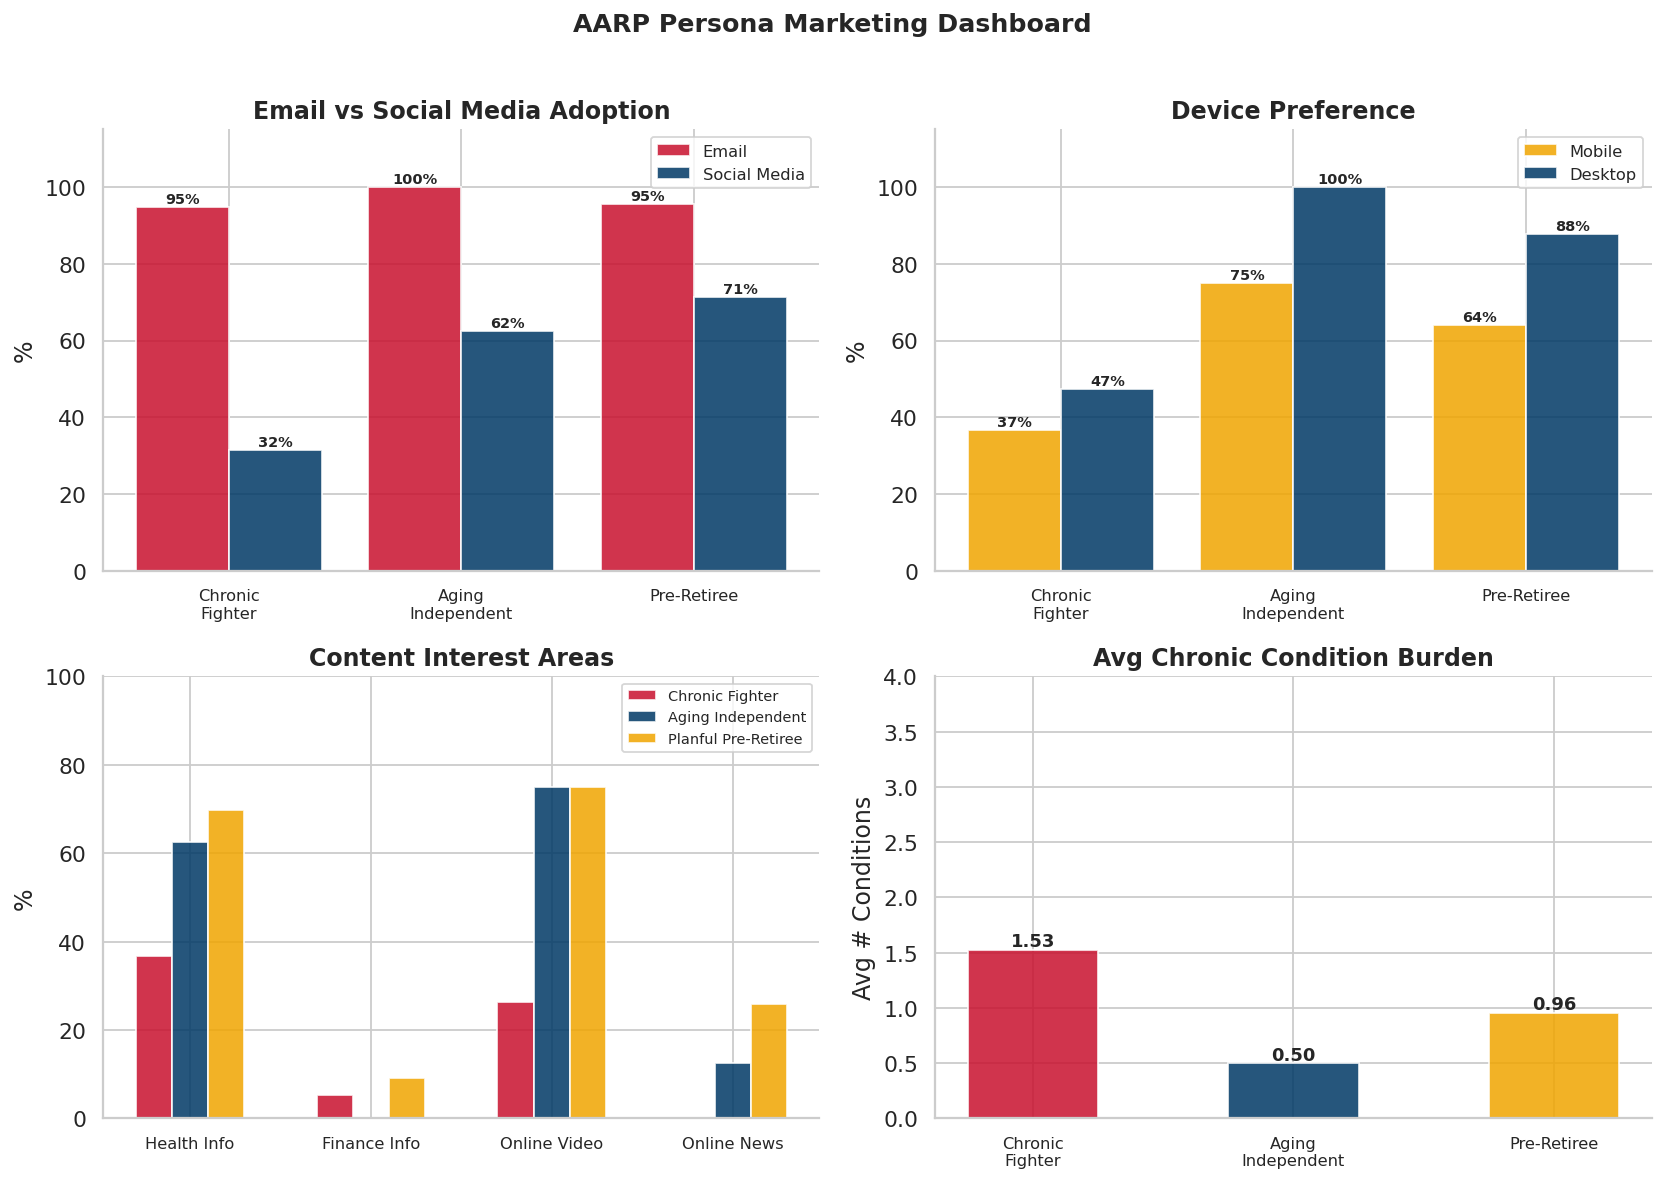

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('AARP Persona Marketing Dashboard', fontweight='bold', fontsize=14, y=1.01)

# ── Top-left: Email vs Social media adoption ─────────────────────────────────
ax = axes[0, 0]
pnames = ['Chronic Fighter', 'Aging Independent', 'Planful Pre-Retiree']
email_vals  = [personas[personas['persona']==p]['uses_email'].mean()*100  for p in pnames]
social_vals = [personas[personas['persona']==p]['uses_social'].mean()*100 for p in pnames]
x = np.arange(len(pnames))
ax.bar(x - 0.2, email_vals,  0.4, label='Email',        color=AARP_RED,  alpha=0.85)
ax.bar(x + 0.2, social_vals, 0.4, label='Social Media', color=AARP_NAVY, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Chronic\nFighter','Aging\nIndependent','Pre-Retiree'], fontsize=9)
ax.set_ylabel('%'); ax.set_ylim(0,115); ax.set_title('Email vs Social Media Adoption', fontweight='bold')
ax.legend(fontsize=9)
for xi, (e, s) in enumerate(zip(email_vals, social_vals)):
    ax.text(xi-0.2, e+1, f'{e:.0f}%', ha='center', fontsize=8, fontweight='bold')
    ax.text(xi+0.2, s+1, f'{s:.0f}%', ha='center', fontsize=8, fontweight='bold')

# ── Top-right: Device split ───────────────────────────────────────────────────
ax = axes[0, 1]
mobile_vals  = [personas[personas['persona']==p]['mobile_user'].mean()*100  for p in pnames]
desktop_vals = [personas[personas['persona']==p]['desktop_user'].mean()*100 for p in pnames]
ax.bar(x - 0.2, mobile_vals,  0.4, label='Mobile',  color=AARP_GOLD, alpha=0.85)
ax.bar(x + 0.2, desktop_vals, 0.4, label='Desktop', color=AARP_NAVY, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Chronic\nFighter','Aging\nIndependent','Pre-Retiree'], fontsize=9)
ax.set_ylabel('%'); ax.set_ylim(0,115); ax.set_title('Device Preference', fontweight='bold')
ax.legend(fontsize=9)
for xi, (m, d) in enumerate(zip(mobile_vals, desktop_vals)):
    ax.text(xi-0.2, m+1, f'{m:.0f}%', ha='center', fontsize=8, fontweight='bold')
    ax.text(xi+0.2, d+1, f'{d:.0f}%', ha='center', fontsize=8, fontweight='bold')

# ── Bottom-left: Content interests ───────────────────────────────────────────
ax = axes[1, 0]
content_vars   = ['seeks_health','seeks_finance','watches_video','reads_news']
content_labels = ['Health Info','Finance Info','Online Video','Online News']
bar_w = 0.2
for i, (pname, color) in enumerate(zip(pnames, PALETTE)):
    seg  = personas[personas['persona'] == pname]
    vals = [seg[v].mean()*100 for v in content_vars]
    xi   = np.arange(len(content_vars)) + i*bar_w
    bars = ax.bar(xi, vals, bar_w, label=pname, color=color, alpha=0.85)
ax.set_xticks(np.arange(len(content_vars)) + bar_w)
ax.set_xticklabels(content_labels, fontsize=9)
ax.set_ylabel('%'); ax.set_ylim(0, 100); ax.set_title('Content Interest Areas', fontweight='bold')
ax.legend(fontsize=8)

# ── Bottom-right: Chronic condition burden ────────────────────────────────────
ax = axes[1, 1]
avg_chronic = [personas[personas['persona']==p]['num_chronic'].mean() for p in pnames]
bars = ax.bar(pnames, avg_chronic, color=PALETTE, alpha=0.85, width=0.5)
for bar, val in zip(bars, avg_chronic):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.03,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticklabels(['Chronic\nFighter','Aging\nIndependent','Pre-Retiree'], fontsize=9)
ax.set_ylabel('Avg # Conditions')
ax.set_title('Avg Chronic Condition Burden', fontweight='bold')
ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()

---
## Key Takeaways

| | Chronic Fighter | Aging Independent | Planful Pre-Retiree |
|---|---|---|---|
| **Lead with** | Condition management & simplicity | Community & independence | Financial clarity & strategy |
| **Avoid** | Complex navigation, mobile-only | Patronizing tone, junk mail | Generic senior messaging |
| **Win metric** | Email open rate, guide downloads | Facebook engagement, event signups | Calculator completions, newsletter subs |

> **Data sources:** Pew Research Internet & Technology Survey (n=1,502); Synthetic CDC BRFSS-aligned health data generated from published age-stratified prevalence rates.